# 02 — Model Evaluation

Load the trained model, run inference on the test set, and report classification metrics (AUROC, confusion matrix).

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report

from src.models.cnn import load_model, print_layers
from src.data.dataset import ArrhythmiaDataset, ARRHYTHMIA_CLASSES

with open('../configs/model.yaml') as f:
    model_cfg = yaml.safe_load(f)
with open('../configs/data.yaml') as f:
    data_cfg = yaml.safe_load(f)

DATA_DIR   = '../' + data_cfg['dataset']['raw_dir']
FS         = data_cfg['signal']['sample_rate']
BATCH_SIZE = model_cfg['inference']['batch_size']
DEVICE     = model_cfg['inference']['device']
CLASSES    = data_cfg['labels']['classes']
SEED       = data_cfg['splits']['seed']
print(f"Classes: {CLASSES}")

Classes: ['SB', 'SR', 'AF', 'ST', 'TWC']


## Load model and inspect layers

In [2]:
trained_path = '../' + model_cfg['model'].get('trained_weights', '')
variant      = model_cfg['model']['name']

if trained_path and os.path.exists(trained_path):
    model = load_model(
        trained_path,
        n_leads=model_cfg['model']['n_leads'],
        n_classes=model_cfg['model']['n_classes'],
        variant=variant,
    )
    print(f"Loaded trained weights: {trained_path}")
else:
    raise FileNotFoundError(
        f"No trained weights found at {trained_path}. "
        "Run 'python train.py' first to train the model."
    )

model = model.to(DEVICE)
print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters\n")
print_layers(model)

Loaded trained weights: ../outputs/models/xresnet1d34_arrhythmia.pt
Model loaded — 7,230,853 parameters

                                                              XResNet
0                                                             ConvLayer
0.0                                                           Conv1d
0.1                                                           BatchNorm1d
0.2                                                           ReLU
1                                                             ConvLayer
1.0                                                           Conv1d
1.1                                                           BatchNorm1d
1.2                                                           ReLU
2                                                             ConvLayer
2.0                                                           Conv1d
2.1                                                           BatchNorm1d
2.2                                           

## Run inference on test set

The model outputs raw logits (one per class), which are passed through `sigmoid` — not softmax — because this is **multi-label** classification. Each output is an independent probability via `BCEWithLogitsLoss`, so multiple classes can be active simultaneously.

In [ ]:
cache_dir = f'../data/preprocessed/{FS}'
test_dataset = ArrhythmiaDataset(
    DATA_DIR, split='test', classes=CLASSES, seed=SEED,
    cache_dir=cache_dir, sampling_rate=FS,
    metadata_path='../data/processed/arrhythmia_metadata.csv',
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # deterministic order for reproducible evaluation

all_probs, all_labels = [], []
model.eval()
with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(DEVICE)
        probs = torch.sigmoid(model(signals)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"Test samples: {len(all_labels):,}  |  Output shape: {all_probs.shape}")

## Per-class AUROC

AUROC is the primary metric because it evaluates **ranking quality** independently of threshold choice. This is especially important for imbalanced multi-label problems where class prevalences vary widely — AUROC measures how well the model separates positive from negative examples regardless of how many there are of each.

In [4]:
aurocs = {}
for i, cls in enumerate(CLASSES):
    if all_labels[:, i].sum() > 0:  # skip classes with no positive examples in test set
        aurocs[cls] = roc_auc_score(all_labels[:, i], all_probs[:, i])
    else:
        aurocs[cls] = float('nan')

print("Per-class AUROC on test set:")
for cls, score in aurocs.items():
    print(f"  {cls:<6}  {score:.4f}")
macro_auroc = np.nanmean(list(aurocs.values()))
print(f"\n  Macro AUROC: {macro_auroc:.4f}")


Per-class AUROC on test set:
  SB      0.9993
  SR      0.9936
  AF      0.9950
  ST      0.9988
  TWC     0.9350

  Macro AUROC: 0.9843


## Classification report and confusion matrix (threshold = 0.5)

The 0.5 threshold is a conventional operating point but not necessarily optimal for each class. The confusion matrices below show how the model trades off false positives vs. false negatives at this threshold. Each class gets its own **binary** confusion matrix because this is multi-label — a record can be positive for multiple classes simultaneously.

Classification report (per-class, threshold = 0.5):
              precision    recall  f1-score   support

          SB       0.99      0.99      0.99      1692
          SR       0.97      0.93      0.95       761
          AF       0.92      0.97      0.94       788
          ST       0.97      0.98      0.97       749
         TWC       0.64      0.79      0.70       721

   micro avg       0.91      0.95      0.93      4711
   macro avg       0.90      0.93      0.91      4711
weighted avg       0.92      0.95      0.93      4711
 samples avg       0.93      0.96      0.93      4711



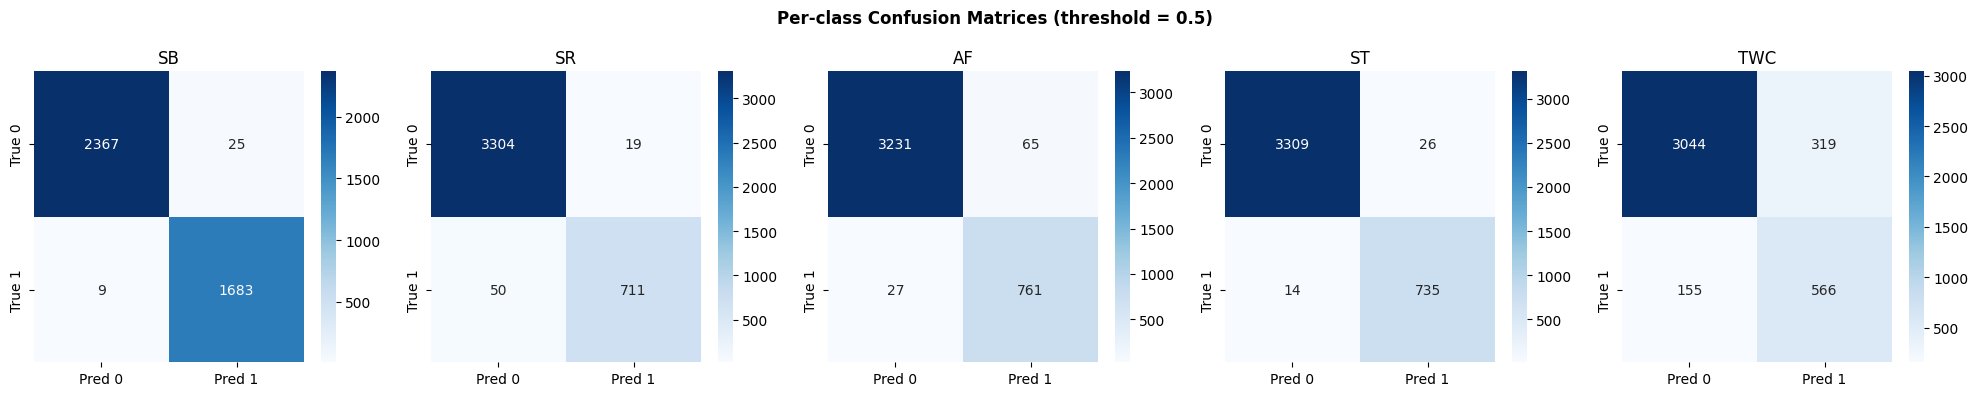

In [5]:
THRESHOLD = 0.5
preds = (all_probs >= THRESHOLD).astype(int)

print("Classification report (per-class, threshold = 0.5):")
print(classification_report(all_labels, preds, target_names=CLASSES, zero_division=0))

# Per-class confusion matrices in a single figure
fig, axes = plt.subplots(1, len(CLASSES), figsize=(4 * len(CLASSES), 4))
for i, (ax, cls) in enumerate(zip(axes, CLASSES)):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(all_labels[:, i], preds[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(cls)
fig.suptitle('Per-class Confusion Matrices (threshold = 0.5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
